In [1]:
import pandas as pd 
df = pd.read_excel('/Users/egorilin/Desktop/COMA/2026_04_14_DataSet_Final_MERGED_FILTERED.xlsx')
smiles = df['SMILES']
smiles

0        C1=CC(=CC=C1N/C(=N/C(=NCCCCCCN=C(/N=C(/NC2=CC=...
1        C1=CC(=CC=C1N/C(=N/C(=NCCCCCCN=C(/N=C(/NC2=CC=...
2        C1=CC(=CC=C1N/C(=N/C(=NCCCCCCN=C(/N=C(/NC2=CC=...
3        C1=CC(=CC=C1N/C(=N/C(=NCCCCCCN=C(/N=C(/NC2=CC=...
4        C1=CC(=CC=C1N/C(=N/C(=NCCCCCCN=C(/N=C(/NC2=CC=...
                               ...                        
10959                                                  NaN
10960                                                  NaN
10961                                                  NaN
10962                                                  NaN
10963                                                  NaN
Name: SMILES, Length: 10964, dtype: object

In [2]:
import torch
from transformers import AutoModel, AutoTokenizer

model = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", deterministic_eval=True, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

smiles = ["Cn1c(=O)c2c(ncn2C)n(C)c1=O", "CC(=O)Oc1ccccc1C(=O)O"]
inputs = tokenizer(smiles, padding=True, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
outputs.pooler_output

tensor([[-0.4407,  0.3902,  0.7989,  ..., -0.6081, -0.0200,  0.0103],
        [ 0.5943,  0.4527,  0.3437,  ...,  0.1520, -0.3464,  0.5590]])

In [3]:
inputs = tokenizer(smiles, padding=True, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
outputs.pooler_output

tensor([[-0.4407,  0.3902,  0.7989,  ..., -0.6081, -0.0200,  0.0103],
        [ 0.5943,  0.4527,  0.3437,  ...,  0.1520, -0.3464,  0.5590]])

In [5]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoModel, AutoTokenizer
from tqdm import tqdm

# Загрузка модели и токенизатора
model = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", deterministic_eval=True, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

# Загрузка данных
data = pd.read_excel("/Users/egorilin/Desktop/COMA/2026_04_14_DataSet_Final_MERGED_FILTERED.xlsx")

# Очистка SMILES: удаляем NaN и пустые строки
smiles_series = data["SMILES"].dropna().astype(str)
smiles_series = smiles_series[smiles_series.str.strip() != ""]
smiles_series = smiles_series[smiles_series.str.lower() != "nan"]

# Создаём маску: какие строки остались после очистки
valid_mask = data["SMILES"].isin(smiles_series)
data_clean = data[valid_mask].copy().reset_index(drop=True)
smiles_list = smiles_series.tolist()

print(f"Исходных строк: {len(data)}")
print(f"После очистки SMILES: {len(data_clean)}")
print(f"SMILES для обработки: {len(smiles_list)}")

# Получение эмбеддингов батчами (чтобы не перегрузить память)
batch_size = 32
all_embeddings = []

for i in tqdm(range(0, len(smiles_list), batch_size), desc="Обработка батчей"):
    batch = smiles_list[i:i + batch_size]
    inputs = tokenizer(batch, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    all_embeddings.append(outputs.pooler_output)

# Объединяем все батчи
embeddings = torch.cat(all_embeddings, dim=0)  # shape: (N, 768)
print(f"Размер эмбеддингов: {embeddings.shape}")

# Добавляем колонки Molformer_* в очищенный датафрейм
n_features = embeddings.shape[1]
molformer_cols = [f'Molformer_{j}' for j in range(n_features)]

# Конвертируем тензор в numpy и добавляем в DataFrame
embeddings_np = embeddings.cpu().numpy()

# Создаём DataFrame с эмбеддингами и соединяем
embeddings_df = pd.DataFrame(embeddings_np, columns=molformer_cols)
data_with_embeddings = pd.concat([data_clean.reset_index(drop=True), embeddings_df], axis=1)

print(f"Итоговый DataFrame: {data_with_embeddings.shape}")
print(f"Добавлено колонок: {n_features}")

# Сохраняем результат
output_path = "/Users/egorilin/Desktop/COMA/2026_04_14_DataSet_Final_MERGED_FILTERED_Molformer.xlsx"
data_with_embeddings.to_excel(output_path, index=False)
print(f"Сохранено: {output_path}")

Исходных строк: 10964
После очистки SMILES: 10101
SMILES для обработки: 10101


Обработка батчей: 100%|██████████| 316/316 [01:27<00:00,  3.60it/s]


Размер эмбеддингов: torch.Size([10101, 768])
Итоговый DataFrame: (10101, 806)
Добавлено колонок: 768
Сохранено: /Users/egorilin/Desktop/COMA/2026_04_14_DataSet_Final_MERGED_FILTERED_Molformer.xlsx


# Make embeddings on multiregression task

01:02:26 | INFO     | ============================================================
01:02:26 | INFO     | ЗАПУСК МУЛЬТИРЕГРЕССИОННОГО ОБУЧЕНИЯ
01:02:26 | INFO     | ============================================================
01:02:26 | INFO     | Device: cpu
01:02:26 | INFO     | PyTorch: 2.4.1
01:02:26 | INFO     | 
01:02:26 | INFO     | ЗАГРУЗКА ДАННЫХ
01:02:26 | INFO     | ============================================================
01:02:26 | INFO     | Путь: /Users/egorilin/Desktop/COMA/2026_04_14_DataSet_Final_MERGED_FILTERED_Molformer.xlsx
01:03:08 | INFO     | ✓ Загружено за 42.34s | Shape: (10101, 806)
01:03:08 | INFO     |   Колонок: 806 | Строк: 10101
01:03:08 | INFO     | 
01:03:08 | INFO     | АНАЛИЗ КОЛОНОК
01:03:08 | INFO     | ============================================================
01:03:08 | INFO     | MoLFormer эмбеддинги: 768 колонок
01:03:08 | INFO     |   Первые 5: ['Molformer_0', 'Molformer_1', 'Molformer_2', 'Molformer_3', 'Molformer_4']
01:03:08 | INFO     

Cleaning targets: 100%|███████████████████████████| 8/8 [00:00<00:00, 85.10it/s]

01:03:08 | INFO     | 
После очистки:
01:03:08 | INFO     |   MIC, ppm                 :   18 валидных | min=2.000 | max=256.000
01:03:08 | INFO     |   MIC, µM                  : 5387 валидных | min=0.030 | max=13700.000
01:03:08 | INFO     |   MBC, µM                  : 1211 валидных | min=0.100 | max=3125.000
01:03:08 | INFO     |   MIC, mg/L                : 4519 валидных | min=0.060 | max=26411.410
01:03:08 | INFO     |   MBC, mg/L                : 1118 валидных | min=0.060 | max=12800.000
01:03:08 | INFO     |   MBIC, mg/L               :   28 валидных | min=0.500 | max=200.000
01:03:08 | INFO     |   MBEC,  mg/L              :   12 валидных | min=2.000 | max=250.000
01:03:08 | INFO     |   MBEC, µM                 :  261 валидных | min=2.350 | max=2000.000
01:03:08 | INFO     | 
Удалено строк без валидных таргетов: 124 (1.2%)
01:03:08 | INFO     | Осталось: 9977 строк
01:03:08 | INFO     | 
Размерности:
01:03:08 | INFO     |   X (эмбеддинги): (9977, 768)
01:03:08 | INFO     |   

01:03:08 | INFO     | ✓ X нормализован за 0.040s
01:03:08 | INFO     | Нормализация таргетов:


Scalers:   0%|                                            | 0/8 [00:00<?, ?it/s]

...

Epochs:  22%|███████▍                          | 44/200 [00:21<01:16,  2.04it/s]

01:03:30 | INFO     | 
✓ Обучение завершено за 21.6s (0.4 мин)
01:03:30 | INFO     | 
01:03:30 | INFO     | ФИНАЛЬНАЯ ОЦЕНКА
01:03:30 | INFO     | ============================================================
01:03:30 | INFO     | ✓ Загружена модель с эпохи 15
01:03:30 | INFO     |   Val loss: 0.0397
01:03:30 | INFO     | Предсказания на test set...



Predicting: 100%|█████████████████████████████| 32/32 [00:00<00:00, 1557.99it/s]

01:03:30 | INFO     |   Предсказания: (1996, 8)
01:03:30 | INFO     |   Эмбеддинги: (1996, 256) (256-мерные)
01:03:30 | INFO     | 
01:03:30 | INFO     | МЕТРИКИ ПО ТАРГЕТАМ
01:03:30 | INFO     | ============================================================
01:03:30 | INFO     | 
  1. MIC, ppm (n=1996):
01:03:30 | INFO     |      RMSE: 0.0220
01:03:30 | INFO     |      MAE:  0.0083
01:03:30 | INFO     |      R²:   -0.8471
01:03:30 | INFO     | 
  2. MIC, µM (n=1996):
01:03:30 | INFO     |      RMSE: 0.3606
01:03:30 | INFO     |      MAE:  0.1476
01:03:30 | INFO     |      R²:   0.7367
01:03:30 | INFO     | 
  3. MBC, µM (n=1996):
01:03:30 | INFO     |      RMSE: 0.3627
01:03:30 | INFO     |      MAE:  0.1132
01:03:30 | INFO     |      R²:   -0.0442
01:03:30 | INFO     | 
  4. MIC, mg/L (n=1996):
01:03:30 | INFO     |      RMSE: 0.1685
01:03:30 | INFO     |      MAE:  0.0719
01:03:30 | INFO     |      R²:   0.9450
01:03:30 | INFO     | 
  5. MBC, mg/L (n=1996):
01:03:30 | INFO     |     

01:03:31 | INFO     | ✓ Сохранено: multireg_training_history.png


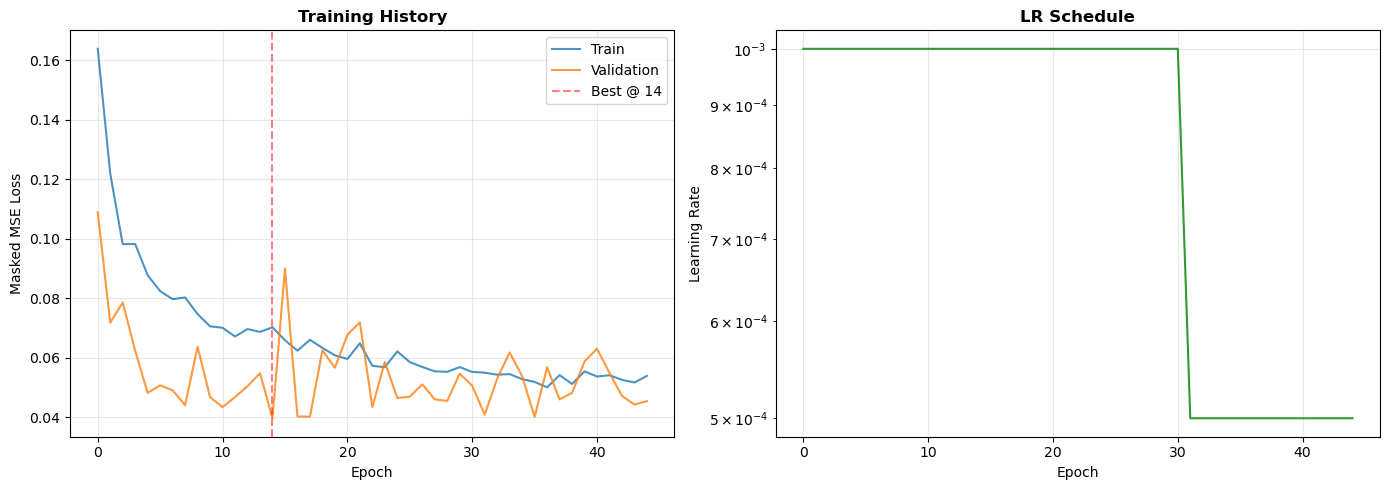

01:03:32 | INFO     | ✓ Сохранено: multireg_scatter_plots.png


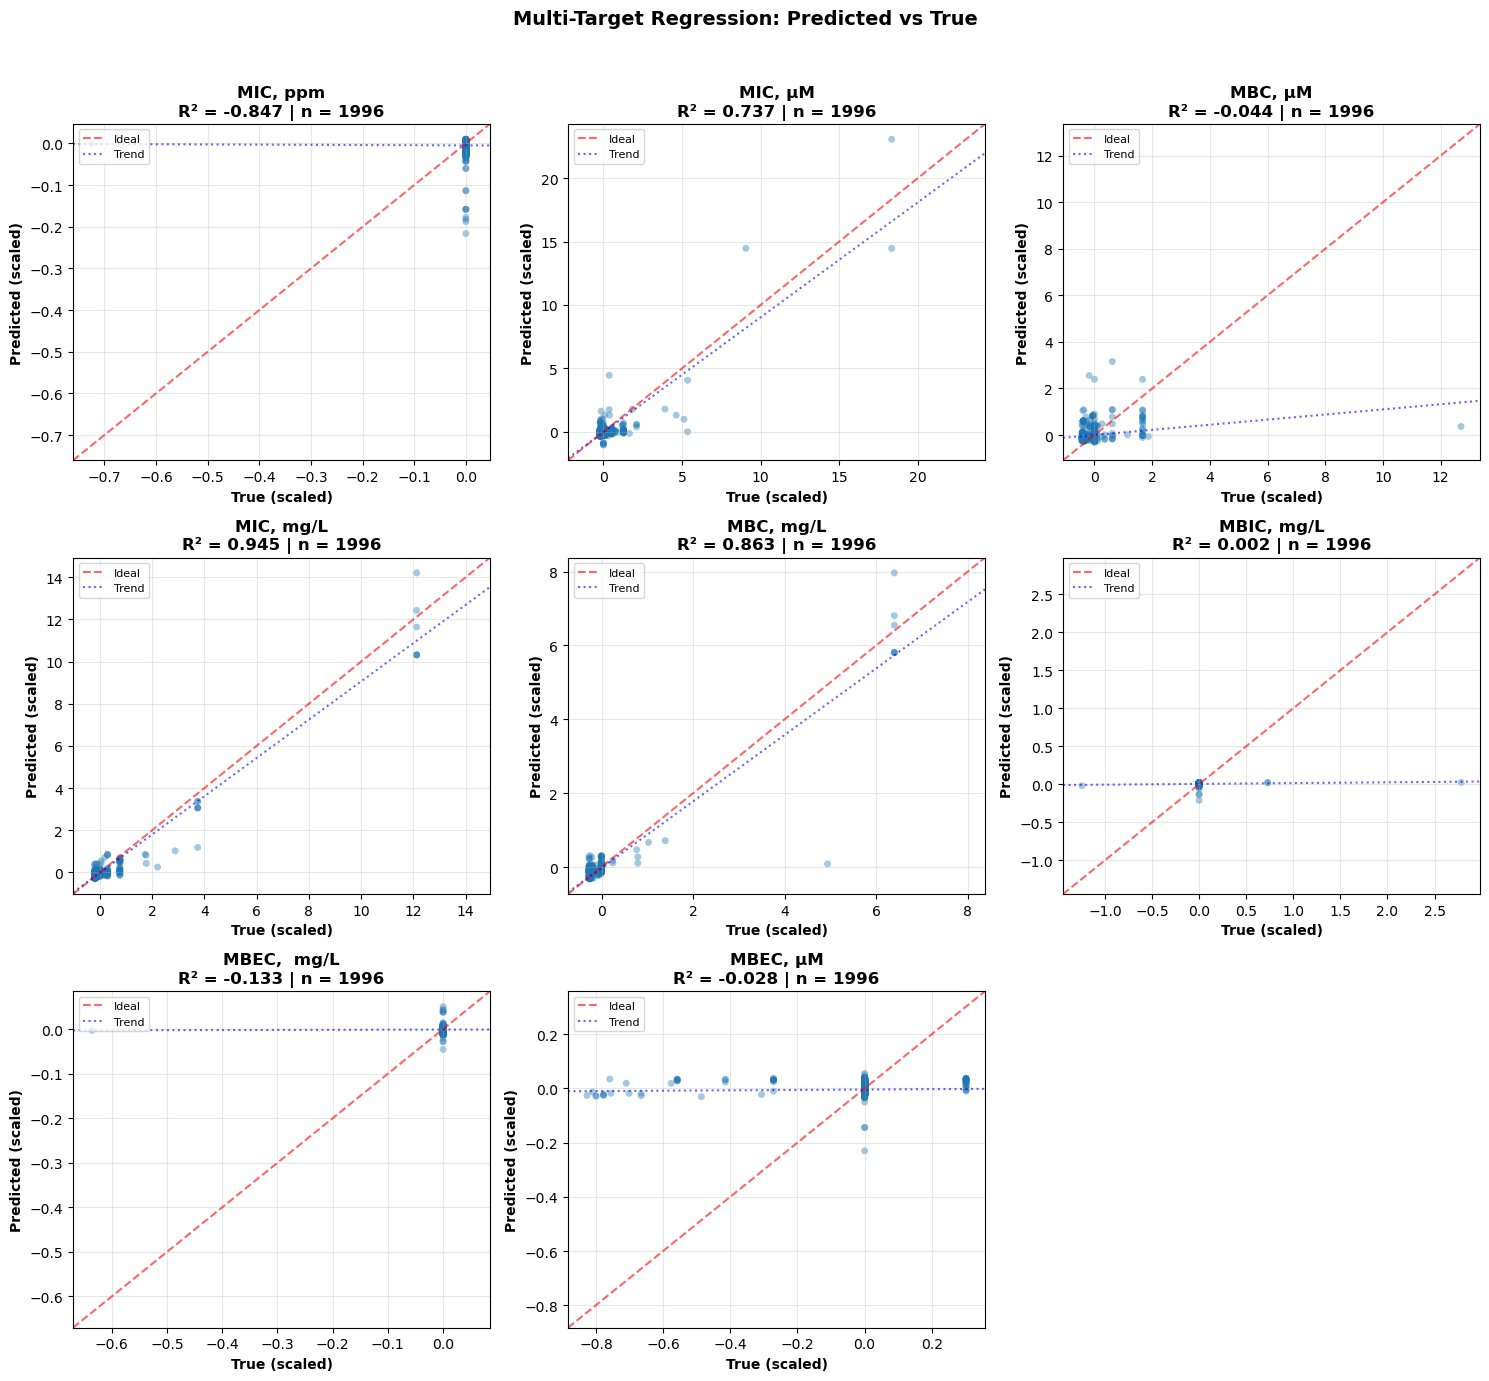

01:03:33 | INFO     | 
01:03:33 | INFO     | СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
01:03:33 | INFO     | ============================================================
01:03:53 | INFO     | ✓ Сохранено: /Users/egorilin/Desktop/COMA/multireg_predictions_with_latent.xlsx
01:03:53 | INFO     |   Колонок: 1070 | Строк: 1996
01:03:53 | INFO     | ✓ Сохранено: multireg_metrics.xlsx
01:03:53 | INFO     | ✓ Сохранено: multireg_model_full.pth
01:03:53 | INFO     | 
01:03:53 | INFO     | ✨ ГОТОВО!
01:03:53 | INFO     | ============================================================
01:03:53 | INFO     | Лог сохранён: /Users/egorilin/Desktop/COMA/training_log.txt


In [1]:
# =============================================================================
# ЯЧЕЙКА 1: ИМПОРТЫ
# =============================================================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import logging
import sys
import time
import re
import warnings
warnings.filterwarnings('ignore')

# Настройка логирования
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(message)s',
    datefmt='%H:%M:%S',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler('/Users/egorilin/Desktop/COMA/training_log.txt', mode='w')
    ]
)
logger = logging.getLogger('MultiReg')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"{'='*60}")
logger.info(f"ЗАПУСК МУЛЬТИРЕГРЕССИОННОГО ОБУЧЕНИЯ")
logger.info(f"{'='*60}")
logger.info(f"Device: {device}")
logger.info(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    logger.info(f"GPU: {torch.cuda.get_device_name(0)}")
    logger.info(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# =============================================================================
# ЯЧЕЙКА 2: ЗАГРУЗКА ДАННЫХ
# =============================================================================
logger.info(f"\n{'='*60}")
logger.info("ЗАГРУЗКА ДАННЫХ")
logger.info(f"{'='*60}")

DATA_PATH = "/Users/egorilin/Desktop/COMA/2026_04_14_DataSet_Final_MERGED_FILTERED_Molformer.xlsx"
logger.info(f"Путь: {DATA_PATH}")

t0 = time.time()
data = pd.read_excel(DATA_PATH)
load_time = time.time() - t0
logger.info(f"✓ Загружено за {load_time:.2f}s | Shape: {data.shape}")
logger.info(f"  Колонок: {data.shape[1]} | Строк: {data.shape[0]}")

# =============================================================================
# ЯЧЕЙКА 3: ОПРЕДЕЛЕНИЕ ТАРГЕТОВ И ПРИЗНАКОВ
# =============================================================================
logger.info(f"\n{'='*60}")
logger.info("АНАЛИЗ КОЛОНОК")
logger.info(f"{'='*60}")

# Эмбеддинги
molformer_cols = [c for c in data.columns if c.startswith('Molformer_')]
logger.info(f"MoLFormer эмбеддинги: {len(molformer_cols)} колонок")
if len(molformer_cols) > 0:
    logger.info(f"  Первые 5: {molformer_cols[:5]}")
    logger.info(f"  Последние 5: {molformer_cols[-5:]}")

# Таргеты — ищем все колонки с MIC/MBC/MBEC в названии
all_cols = data.columns.tolist()
target_cols = []
for c in all_cols:
    c_upper = c.upper()
    if any(x in c_upper for x in ['MIC', 'MBC', 'MBEC', 'MBIC']) and c not in molformer_cols:
        target_cols.append(c)

# Удаляем дубликаты сохраняя порядок
target_cols = list(dict.fromkeys(target_cols))

logger.info(f"\nНайдено потенциальных таргетов: {len(target_cols)}")
for i, t in enumerate(target_cols, 1):
    non_null = data[t].notna().sum()
    logger.info(f"  {i:2d}. {t} | Не-NaN: {non_null}/{len(data)} ({100*non_null/len(data):.1f}%)")

if len(target_cols) == 0:
    logger.error("Нет таргетов! Все колонки:")
    for i, c in enumerate(all_cols, 1):
        logger.info(f"  {i:2d}. {c}")
    raise ValueError("Не найдено ни одного таргета!")

# =============================================================================
# ЯЧЕЙКА 4: ОЧИСТКА ДАННЫХ (ИСПРАВЛЕННАЯ)
# =============================================================================
logger.info(f"\n{'='*60}")
logger.info("ОЧИСТКА ДАННЫХ")
logger.info(f"{'='*60}")

def clean_numeric_advanced(series, col_name):
    """Извлекает числа из строк, включая '>500', '<0.1', 'Ю500' и т.д."""
    s = series.copy()
    
    # Если уже числовая — просто вернём как float
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float)
    
    # Преобразуем в строку
    s = s.astype(str)
    
    # Покажем уникальные нечисловые значения
    def extract_number(x):
        if pd.isna(x) or str(x).lower() in ('nan', 'none', '', 'nat'):
            return np.nan
        # Ищем число в строке: поддерживает десятичные, экспоненциальные, отрицательные
        match = re.search(r'-?\d+\.?\d*(?:[eE][+-]?\d+)?', str(x))
        if match:
            return float(match.group())
        return np.nan
    
    # Применяем извлечение чисел
    cleaned = s.apply(extract_number)
    
    # Логируем что не смогли распарсить
    still_bad_mask = cleaned.isna() & series.notna()
    still_bad = series[still_bad_mask]
    
    if len(still_bad) > 0:
        unique_bad = still_bad.unique()[:10]
        logger.warning(f"  {col_name}: не распарсено {len(still_bad)} значений:")
        for val in unique_bad:
            count = (series == val).sum()
            logger.warning(f"    '{val}' — {count} раз(а)")
        if len(still_bad.unique()) > 10:
            logger.warning(f"    ... и ещё {len(still_bad.unique())-10} уникальных")
    
    # Логируем успешно распарсенные граничные случаи
    parsed_mask = series.notna() & cleaned.notna() & (s != series.astype(str))
    if parsed_mask.sum() > 0:
        examples = series[parsed_mask].unique()[:5]
        logger.info(f"  {col_name}: распарсено {parsed_mask.sum()} строковых значений, напр: {list(examples)}")
    
    return cleaned

# Очищаем каждый таргет
logger.info("\nОчистка таргетов...")
for col in tqdm(target_cols, desc="Cleaning targets", ncols=80):
    data[col] = clean_numeric_advanced(data[col], col)

# Проверяем результат очистки
logger.info("\nПосле очистки:")
for col in target_cols:
    non_nan = data[col].notna().sum()
    logger.info(f"  {col:25s}: {non_nan:4d} валидных | min={data[col].min():.3f} | max={data[col].max():.3f}")

# Фильтруем строки с хотя бы одним валидным таргетом
has_any_target = data[target_cols].notna().any(axis=1)
data_clean = data[has_any_target].copy().reset_index(drop=True)
removed = len(data) - len(data_clean)
logger.info(f"\nУдалено строк без валидных таргетов: {removed} ({100*removed/len(data):.1f}%)")
logger.info(f"Осталось: {len(data_clean)} строк")

# Признаки и таргеты
X = data_clean[molformer_cols].values.astype(np.float32)
y = data_clean[target_cols].values.astype(np.float32)

logger.info(f"\nРазмерности:")
logger.info(f"  X (эмбеддинги): {X.shape}")
logger.info(f"  y (таргеты):    {y.shape}")

# Статистика по NaN в таргетах
nan_stats = pd.DataFrame(y, columns=target_cols).isna().sum()
logger.info(f"\nNaN в таргетах (после очистки):")
for col, nan_count in nan_stats.items():
    pct = 100 * nan_count / len(data_clean)
    logger.info(f"  {col:25s}: {nan_count:4d} ({pct:5.1f}%)")

# =============================================================================
# ЯЧЕЙКА 5: НОРМАЛИЗАЦИЯ
# =============================================================================
logger.info(f"\n{'='*60}")
logger.info("НОРМАЛИЗАЦИЯ")
logger.info(f"{'='*60}")

t0 = time.time()
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
logger.info(f"✓ X нормализован за {time.time()-t0:.3f}s")

# Нормализация таргетов по колонкам (сохраняем scalers)
scalers_y = {}
y_scaled = np.zeros_like(y)

logger.info("Нормализация таргетов:")
for i, col in enumerate(tqdm(target_cols, desc="Scalers", ncols=80)):
    col_data = y[:, i]
    valid_mask = ~np.isnan(col_data)
    valid_count = valid_mask.sum()
    
    if valid_count > 1:
        scaler = StandardScaler()
        valid_values = col_data[valid_mask].reshape(-1, 1)
        scaler.fit(valid_values)
        scalers_y[col] = scaler
        y_scaled[valid_mask, i] = scaler.transform(valid_values).flatten()
        logger.info(f"  ✓ {col:25s}: μ={scaler.mean_[0]:.3f}, σ={np.sqrt(scaler.var_[0]):.3f}, n={valid_count}")
    else:
        logger.warning(f"  ✗ {col:25s}: недостаточно данных ({valid_count} точек)")

# =============================================================================
# ЯЧЕЙКА 6: РАЗДЕЛЕНИЕ TRAIN/TEST
# =============================================================================
logger.info(f"\n{'='*60}")
logger.info("РАЗДЕЛЕНИЕ TRAIN/TEST")
logger.info(f"{'='*60}")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

logger.info(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
logger.info(f"Соотношение: {X_train.shape[0]/X_test.shape[0]:.1f}:1")

# =============================================================================
# ЯЧЕЙКА 7: DATASET И DATALOADER
# =============================================================================
logger.info(f"\n{'='*60}")
logger.info("СОЗДАНИЕ DATASETS")
logger.info(f"{'='*60}")

class MultiTargetRegressionDataset(Dataset):
    def __init__(self, X, y, name="dataset"):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.name = name
        logger.info(f"  {name}: {len(self)} образцов")
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MultiTargetRegressionDataset(X_train, y_train, "Train")
test_dataset = MultiTargetRegressionDataset(X_test, y_test, "Test")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

logger.info(f"  Batch size: 64")
logger.info(f"  Train batches: {len(train_loader)}")
logger.info(f"  Test batches: {len(test_loader)}")

# =============================================================================
# ЯЧЕЙКА 8: МОДЕЛЬ
# =============================================================================
logger.info(f"\n{'='*60}")
logger.info("АРХИТЕКТУРА МОДЕЛИ")
logger.info(f"{'='*60}")

class MultiRegressionMoLFormer(nn.Module):
    def __init__(self, input_dim, hidden_dims, embedding_dim, output_dim, dropout=0.3):
        super().__init__()
        self.input_dim = input_dim
        self.embedding_dim = embedding_dim
        
        # Encoder
        layers = []
        prev = input_dim
        for i, h in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev = h
            logger.info(f"  Layer {i+1}: {prev} -> {h}")
        
        layers.extend([
            nn.Linear(prev, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.ReLU()
        ])
        logger.info(f"  Embedding: {prev} -> {embedding_dim}")
        
        self.encoder = nn.Sequential(*layers)
        
        # Regressor
        self.regressor = nn.Sequential(
            nn.Dropout(dropout / 2),
            nn.Linear(embedding_dim, output_dim)
        )
        logger.info(f"  Output: {embedding_dim} -> {output_dim} (таргетов)")
        
        # Подсчёт параметров
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        logger.info(f"\nПараметры: {total:,} всего | {trainable:,} обучаемых")
        
    def forward(self, x, return_embedding=False):
        emb = self.encoder(x)
        out = self.regressor(emb)
        if return_embedding:
            return out, emb
        return out

model = MultiRegressionMoLFormer(
    input_dim=len(molformer_cols),
    hidden_dims=[512, 384],
    embedding_dim=256,
    output_dim=len(target_cols),
    dropout=0.3
).to(device)

# =============================================================================
# ЯЧЕЙКА 9: MASKED LOSS
# =============================================================================
class MaskedMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        
    def forward(self, pred, target):
        mask = ~torch.isnan(target)
        n_valid = mask.sum()
        
        if n_valid == 0:
            logger.warning("Batch: все таргеты NaN!")
            return torch.tensor(0.0, requires_grad=True, device=pred.device)
        
        loss = F.mse_loss(pred, target, reduction='none')
        loss = loss * mask.float()
        return loss.sum() / n_valid

criterion = MaskedMSELoss()
logger.info(f"\nLoss: MaskedMSELoss")

# =============================================================================
# ЯЧЕЙКА 10: ОПТИМИЗАТОР И ОБУЧЕНИЕ
# =============================================================================
logger.info(f"\n{'='*60}")
logger.info("ОБУЧЕНИЕ")
logger.info(f"{'='*60}")

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=15, verbose=False
)

num_epochs = 200
best_val_loss = float('inf')
patience = 30
patience_counter = 0

logger.info(f"Epochs: {num_epochs}")
logger.info(f"Optimizer: AdamW (lr=1e-3, wd=1e-4)")
logger.info(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=15)")
logger.info(f"Early stopping: patience={patience}")

history = {'train_loss': [], 'val_loss': [], 'lr': []}

logger.info(f"\n{'='*60}")
logger.info("НАЧАЛО ОБУЧЕНИЯ")
logger.info(f"{'='*60}")

total_start = time.time()

for epoch in tqdm(range(num_epochs), desc="Epochs", ncols=80, position=0):
    epoch_start = time.time()
    
    # ---- Train ----
    model.train()
    train_losses = []
    
    for batch_idx, (X_batch, y_batch) in enumerate(
        tqdm(train_loader, desc=f"Train {epoch+1}", ncols=80, leave=False, position=1)
    ):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        
        if loss.item() > 0:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        train_losses.append(loss.item())
        
        if batch_idx % 50 == 0 and batch_idx > 0:
            logger.debug(f"  Batch {batch_idx:3d}/{len(train_loader)} | Loss: {loss.item():.4f}")
    
    avg_train = np.mean(train_losses)
    
    # ---- Validation ----
    model.eval()
    val_losses = []
    
    with torch.no_grad():
        for X_batch, y_batch in tqdm(test_loader, desc=f"Val {epoch+1}", ncols=80, leave=False, position=1):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            val_losses.append(loss.item())
    
    avg_val = np.mean(val_losses)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    history['lr'].append(current_lr)
    
    scheduler.step(avg_val)
    
    epoch_time = time.time() - epoch_start
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        logger.info(
            f"Epoch {epoch+1:3d}/{num_epochs} | "
            f"Train: {avg_train:.4f} | Val: {avg_val:.4f} | "
            f"LR: {current_lr:.2e} | Time: {epoch_time:.1f}s"
        )
    
    # Early stopping
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_loss': avg_val,
            'history': history,
        }, '/Users/egorilin/Desktop/COMA/best_multireg_model.pth')
        if (epoch + 1) % 10 == 0:
            logger.info(f"  💾 Сохранена лучшая модель (val_loss={avg_val:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            logger.info(f"\n⏹ Early stopping на эпохе {epoch+1}")
            logger.info(f"   Лучший val_loss: {best_val_loss:.4f}")
            break

total_time = time.time() - total_start
logger.info(f"\n✓ Обучение завершено за {total_time:.1f}s ({total_time/60:.1f} мин)")

# =============================================================================
# ЯЧЕЙКА 11: ЗАГРУЗКА ЛУЧШЕЙ МОДЕЛИ
# =============================================================================
logger.info(f"\n{'='*60}")
logger.info("ФИНАЛЬНАЯ ОЦЕНКА")
logger.info(f"{'='*60}")

checkpoint = torch.load('/Users/egorilin/Desktop/COMA/best_multireg_model.pth')
model.load_state_dict(checkpoint['model_state'])
logger.info(f"✓ Загружена модель с эпохи {checkpoint['epoch']+1}")
logger.info(f"  Val loss: {checkpoint['val_loss']:.4f}")

# =============================================================================
# ЯЧЕЙКА 12: ПРЕДСКАЗАНИЯ
# =============================================================================
model.eval()
all_preds = []
all_true = []
all_embeddings = []

logger.info("Предсказания на test set...")
with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc="Predicting", ncols=80):
        X_batch = X_batch.to(device)
        pred, emb = model(X_batch, return_embedding=True)
        all_preds.append(pred.cpu().numpy())
        all_true.append(y_batch.numpy())
        all_embeddings.append(emb.cpu().numpy())

preds = np.concatenate(all_preds, axis=0)
true = np.concatenate(all_true, axis=0)
embeddings = np.concatenate(all_embeddings, axis=0)

logger.info(f"  Предсказания: {preds.shape}")
logger.info(f"  Эмбеддинги: {embeddings.shape} (256-мерные)")

# =============================================================================
# ЯЧЕЙКА 13: МЕТРИКИ
# =============================================================================
logger.info(f"\n{'='*60}")
logger.info("МЕТРИКИ ПО ТАРГЕТАМ")
logger.info(f"{'='*60}")

metrics_summary = []

for i, col in enumerate(target_cols):
    mask = ~np.isnan(true[:, i])
    n = mask.sum()
    
    if n == 0:
        logger.warning(f"  ✗ {col}: нет данных!")
        continue
    
    y_t = true[mask, i]
    y_p = preds[mask, i]
    
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae = mean_absolute_error(y_t, y_p)
    r2 = r2_score(y_t, y_p)
    
    metrics_summary.append({
        'Target': col,
        'N': int(n),
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })
    
    logger.info(f"\n  {i+1}. {col} (n={n}):")
    logger.info(f"     RMSE: {rmse:.4f}")
    logger.info(f"     MAE:  {mae:.4f}")
    logger.info(f"     R²:   {r2:.4f}")

metrics_df = pd.DataFrame(metrics_summary)
logger.info(f"\n{'='*60}")
logger.info("СВОДНАЯ ТАБЛИЦА")
logger.info(f"{'='*60}")
for _, row in metrics_df.iterrows():
    logger.info(
        f"{row['Target']:25s} | N={row['N']:3d} | "
        f"RMSE={row['RMSE']:.4f} | MAE={row['MAE']:.4f} | R²={row['R2']:+.3f}"
    )

avg_r2 = metrics_df['R2'].mean()
logger.info(f"\nСредний R²: {avg_r2:.3f}")

# =============================================================================
# ЯЧЕЙКА 14: ВИЗУАЛИЗАЦИЯ
# =============================================================================
logger.info(f"\n{'='*60}")
logger.info("ВИЗУАЛИЗАЦИЯ")
logger.info(f"{'='*60}")

# 1. Кривые обучения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(history['train_loss'], label='Train', alpha=0.8, linewidth=1.5)
ax.plot(history['val_loss'], label='Validation', alpha=0.8, linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Masked MSE Loss')
ax.set_title('Training History', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
best_epoch = np.argmin(history['val_loss'])
ax.axvline(best_epoch, color='r', linestyle='--', alpha=0.5, label=f'Best @ {best_epoch}')
ax.legend()

ax = axes[1]
ax.plot(history['lr'], color='green', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('LR Schedule', fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/egorilin/Desktop/COMA/multireg_training_history.png', dpi=300, bbox_inches='tight')
logger.info("✓ Сохранено: multireg_training_history.png")
plt.show()

# 2. Scatter plots
n_targets = len(metrics_summary)
ncols = 3
nrows = (n_targets + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5*nrows))
axes = axes.flatten() if n_targets > 1 else [axes]

for idx, row in enumerate(metrics_summary):
    i = target_cols.index(row['Target'])
    mask = ~np.isnan(true[:, i])
    y_t = true[mask, i]
    y_p = preds[mask, i]
    
    ax = axes[idx]
    ax.scatter(y_t, y_p, alpha=0.4, s=25, edgecolors='none')
    
    lims = [min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())]
    pad = (lims[1] - lims[0]) * 0.05
    lims = [lims[0]-pad, lims[1]+pad]
    ax.plot(lims, lims, 'r--', alpha=0.6, linewidth=1.5, label='Ideal')
    
    z = np.polyfit(y_t, y_p, 1)
    p = np.poly1d(z)
    ax.plot(lims, p(lims), 'b:', alpha=0.6, linewidth=1.5, label='Trend')
    
    ax.set_title(f"{row['Target']}\nR² = {row['R2']:.3f} | n = {row['N']}", fontweight='bold')
    ax.set_xlabel('True (scaled)', fontweight='bold')
    ax.set_ylabel('Predicted (scaled)', fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

for j in range(idx+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Multi-Target Regression: Predicted vs True', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/egorilin/Desktop/COMA/multireg_scatter_plots.png', dpi=300, bbox_inches='tight')
logger.info("✓ Сохранено: multireg_scatter_plots.png")
plt.show()

# =============================================================================
# ЯЧЕЙКА 15: СОХРАНЕНИЕ
# =============================================================================
logger.info(f"\n{'='*60}")
logger.info("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
logger.info(f"{'='*60}")

pred_df = pd.DataFrame(
    preds, 
    columns=[f'{c}_pred' for c in target_cols],
    index=data_clean.index[:len(preds)]
)

emb_cols = [f'Latent_{i}' for i in range(256)]
emb_df = pd.DataFrame(embeddings, columns=emb_cols, index=pred_df.index)

results_df = pd.concat([
    data_clean.iloc[:len(preds)].reset_index(drop=True),
    pred_df.reset_index(drop=True),
    emb_df.reset_index(drop=True)
], axis=1)

save_path = '/Users/egorilin/Desktop/COMA/multireg_predictions_with_latent.xlsx'
results_df.to_excel(save_path, index=False)
logger.info(f"✓ Сохранено: {save_path}")
logger.info(f"  Колонок: {results_df.shape[1]} | Строк: {results_df.shape[0]}")

metrics_df.to_excel('/Users/egorilin/Desktop/COMA/multireg_metrics.xlsx', index=False)
logger.info("✓ Сохранено: multireg_metrics.xlsx")

torch.save({
    'model_state': model.state_dict(),
    'scaler_X': scaler_X,
    'scalers_y': scalers_y,
    'target_cols': target_cols,
    'molformer_cols': molformer_cols,
    'metrics': metrics_summary,
    'history': history,
    'config': {
        'input_dim': len(molformer_cols),
        'hidden_dims': [512, 384],
        'embedding_dim': 256,
        'output_dim': len(target_cols),
    }
}, '/Users/egorilin/Desktop/COMA/multireg_model_full.pth')
logger.info("✓ Сохранено: multireg_model_full.pth")

logger.info(f"\n{'='*60}")
logger.info("✨ ГОТОВО!")
logger.info(f"{'='*60}")
logger.info(f"Лог сохранён: /Users/egorilin/Desktop/COMA/training_log.txt")

# Check results for the regression embeddings

In [ ]:
# =============================================================================
# ЯЧЕЙКА 1: ИМПОРТЫ
# =============================================================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from scipy.stats import pearsonr
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm
import logging
import sys
import time
import re
import warnings
warnings.filterwarnings('ignore')

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(message)s',
    datefmt='%H:%M:%S',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler('/Users/egorilin/Desktop/COMA/multitask_stratify_log.txt', mode='w')
    ]
)
logger = logging.getLogger('MultiTaskStratify')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"{'='*80}")
logger.info("MULTI-TASK STRATIFY + LOG2 ТАРГЕТЫ")
logger.info(f"{'='*80}")
logger.info(f"Device: {device}")

BASE_PATH = "/Users/egorilin/Desktop/COMA"

# =============================================================================
# ЯЧЕЙКА 2: ЗАГРУЗКА ДАННЫХ
# =============================================================================
logger.info(f"\n{'='*80}")
logger.info("ЗАГРУЗКА ДАННЫХ")
logger.info(f"{'='*80}")

DATA_PATH = f"{BASE_PATH}/2026_04_14_DataSet_Final_MERGED_FILTERED_Molformer.xlsx"
t0 = time.time()
data = pd.read_excel(DATA_PATH)
logger.info(f"✓ Загружено за {time.time()-t0:.2f}s | Shape: {data.shape}")

# =============================================================================
# ЯЧЕЙКА 3: КОЛОНКИ
# =============================================================================
logger.info(f"\n{'='*80}")
logger.info("АНАЛИЗ КОЛОНОК")
logger.info(f"{'='*80}")

molformer_cols = [c for c in data.columns if c.startswith('Molformer_')]
logger.info(f"MoLFormer: {len(molformer_cols)} колонок")

target_cols = []
for c in data.columns:
    if any(x in c.upper() for x in ['MIC', 'MBC', 'MBEC', 'MBIC']) and c not in molformer_cols:
        target_cols.append(c)

target_cols = list(dict.fromkeys(target_cols))
logger.info(f"Таргетов: {len(target_cols)}")
for i, t in enumerate(target_cols, 1):
    non_null = data[t].notna().sum()
    logger.info(f"  {i:2d}. {t} | Не-NaN: {non_null}/{len(data)} ({100*non_null/len(data):.1f}%)")

# =============================================================================
# ЯЧЕЙКА 4: ОЧИСТКА + LOG2
# =============================================================================
logger.info(f"\n{'='*80}")
logger.info("ОЧИСТКА И LOG2 ТРАНСФОРМАЦИЯ")
logger.info(f"{'='*80}")

def clean_numeric(series, col_name):
    s = series.copy()
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float)
    
    s = s.astype(str)
    def extract(x):
        if pd.isna(x) or str(x).lower() in ('nan', 'none', '', 'nat'):
            return np.nan
        m = re.search(r'-?\d+\.?\d*(?:[eE][+-]?\d+)?', str(x))
        return float(m.group()) if m else np.nan
    
    cleaned = s.apply(extract)
    bad = cleaned.isna() & series.notna()
    if bad.sum() > 0:
        logger.warning(f"  {col_name}: не распарсено {bad.sum()}: {list(series[bad].unique()[:3])}")
    return cleaned

# Очищаем и применяем log2
for col in tqdm(target_cols, desc="Clean", ncols=80):
    data[col] = clean_numeric(data[col], col)

# Log2 трансформация (только положительные значения)
logger.info("\nLog2 трансформация:")
for col in target_cols:
    valid = data[col].notna() & (data[col] > 0)
    if valid.sum() > 0:
        data.loc[valid, col] = np.log2(data.loc[valid, col])
        logger.info(f"  {col}: log2 применён к {valid.sum()} значениям")
    else:
        logger.warning(f"  {col}: нет положительных значений!")

# Фильтруем
has_any = data[target_cols].notna().any(axis=1)
data_clean = data[has_any].copy().reset_index(drop=True)
logger.info(f"\nОсталось: {len(data_clean)} строк")

X_contr = data_clean[molformer_cols].values.astype(np.float32)

# =============================================================================
# ЯЧЕЙКА 5: STRATIFY С ОБЪЕДИНЕНИЕМ РЕДКИХ ГРУПП
# =============================================================================
logger.info(f"\n{'='*80}")
logger.info("STRATIFY (С ОБЪЕДИНЕНИЕМ РЕДКИХ)")
logger.info(f"{'='*80}")

task_presence = data_clean[target_cols].notna().astype(int).values

# Среднее доступных таргетов
available_means = []
for i in range(len(data_clean)):
    vals = data_clean[target_cols].iloc[i].dropna().values
    available_means.append(np.mean(vals) if len(vals) > 0 else np.nan)

available_means = np.array(available_means)
quantiles = pd.qcut(available_means, q=3, labels=['low', 'mid', 'high'], duplicates='drop')
quantile_labels = quantiles.astype(str)

# Composite label
task_patterns = [''.join(map(str, row)) for row in task_presence]
composite_labels = [f"{tp}_{ql}" for tp, ql in zip(task_patterns, quantile_labels)]

# Подсчитываем частоты
label_counts = Counter(composite_labels)
logger.info(f"Уникальных групп: {len(label_counts)}")

# Объединяем редкие группы (< 2 образцов) в "OTHER"
MIN_GROUP_SIZE = 2
merged_labels = []
for label in composite_labels:
    if label_counts[label] < MIN_GROUP_SIZE:
        merged_labels.append("OTHER")
    else:
        merged_labels.append(label)

# Проверяем после объединения
merged_counts = Counter(merged_labels)
logger.info(f"После объединения (<{MIN_GROUP_SIZE}): {len(merged_counts)} групп")
logger.info(f"Распределение:")
for val, count in merged_counts.most_common(10):
    logger.info(f"  {val}: {count}")

# Проверяем что нет групп с 1 элементом
if min(merged_counts.values()) < MIN_GROUP_SIZE and "OTHER" not in merged_counts:
    logger.error("Всё ещё есть группы с 1 элементом! Увеличьте MIN_GROUP_SIZE")
    raise ValueError("Stratify невозможен")

le_strat = LabelEncoder()
stratify_y = le_strat.fit_transform(merged_labels)

# =============================================================================
# ЯЧЕЙКА 6: SPLIT СОХРАНЯЯ ИНДЕКСЫ
# =============================================================================
logger.info(f"\n{'='*80}")
logger.info("TRAIN/TEST SPLIT")
logger.info(f"{'='*80}")

indices = np.arange(len(data_clean))

train_idx, test_idx, strat_train, strat_test = train_test_split(
    indices, stratify_y, test_size=0.2, random_state=42, stratify=stratify_y
)

logger.info(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

# Признаки
X_train = X_contr[train_idx]
X_test = X_contr[test_idx]

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# =============================================================================
# ЯЧЕЙКА 7: ТАРГЕТЫ (LOG2 УЖЕ ПРИМЕНЁН)
# =============================================================================
logger.info(f"\n{'='*80}")
logger.info("ПОДГОТОВКА ТАРГЕТОВ")
logger.info(f"{'='*80}")

y_train = data_clean.iloc[train_idx][target_cols].values.astype(np.float32)
y_test = data_clean.iloc[test_idx][target_cols].values.astype(np.float32)

logger.info(f"Train: {y_train.shape} | Test: {y_test.shape}")

# Нормализация (уже log2)
scalers_y = {}
y_train_scaled = np.zeros_like(y_train)
y_test_scaled = np.zeros_like(y_test)

for i, col in enumerate(tqdm(target_cols, desc="Scale", ncols=80)):
    valid_train = ~np.isnan(y_train[:, i])
    if valid_train.sum() > 1:
        scaler = StandardScaler()
        scaler.fit(y_train[valid_train, i].reshape(-1, 1))
        scalers_y[col] = scaler
        y_train_scaled[valid_train, i] = scaler.transform(
            y_train[valid_train, i].reshape(-1, 1)
        ).flatten()
        
        valid_test = ~np.isnan(y_test[:, i])
        if valid_test.sum() > 0:
            y_test_scaled[valid_test, i] = scaler.transform(
                y_test[valid_test, i].reshape(-1, 1)
            ).flatten()

logger.info(f"✓ Scalers: {len(scalers_y)}")

# =============================================================================
# ЯЧЕЙКА 8: МОДЕЛЬ
# =============================================================================
logger.info(f"\n{'='*80}")
logger.info("МОДЕЛЬ")
logger.info(f"{'='*80}")

class MultiTaskRegressionModel(nn.Module):
    def __init__(self, input_dim, hidden_dims, embedding_dim, output_dim, dropout=0.3):
        super().__init__()
        self.embedding_dim = embedding_dim
        
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)
            ])
            prev = h
        
        layers.extend([
            nn.Linear(prev, embedding_dim), nn.BatchNorm1d(embedding_dim), nn.ReLU()
        ])
        self.encoder = nn.Sequential(*layers)
        
        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Dropout(dropout/2), nn.Linear(embedding_dim, 64), nn.ReLU(),
                nn.Linear(64, 1)
            ) for _ in range(output_dim)
        ])
        
        self.task_embedding = nn.Embedding(output_dim, embedding_dim)
        
        total = sum(p.numel() for p in self.parameters())
        logger.info(f"Параметры: {total:,}")
        logger.info(f"  {input_dim} -> {hidden_dims} -> {embedding_dim} -> {output_dim} heads")
        
    def forward(self, x, task_id=None, return_embedding=False):
        emb = self.encoder(x)
        if task_id is not None:
            emb = emb + self.task_embedding(task_id)
        out = torch.cat([head(emb) for head in self.heads], dim=1)
        return (out, emb) if return_embedding else out

# =============================================================================
# ЯЧЕЙКА 9: DATASET
# =============================================================================
class MultiTaskDataset(Dataset):
    def __init__(self, X, y, name="dataset"):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        logger.info(f"  {name}: {len(self)} samples, {y.shape[1]} targets")
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_dataset = MultiTaskDataset(X_train_scaled, y_train_scaled, "Train")
test_dataset = MultiTaskDataset(X_test_scaled, y_test_scaled, "Test")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# =============================================================================
# ЯЧЕЙКА 10: LOSS
# =============================================================================
class MaskedMSELoss(nn.Module):
    def __init__(self, weights=None):
        super().__init__()
        self.weights = weights
        
    def forward(self, pred, target):
        mask = ~torch.isnan(target)
        n = mask.sum()
        if n == 0:
            return torch.tensor(0.0, requires_grad=True, device=pred.device)
        
        loss = F.mse_loss(pred, target, reduction='none') * mask.float()
        if self.weights is not None:
            loss = loss * self.weights.to(pred.device).unsqueeze(0)
        return loss.sum() / n

# Веса таргетов
weights = []
for i, col in enumerate(target_cols):
    r = (~np.isnan(y_train[:, i])).mean()
    weights.append(1.0 / (r + 0.1))
weights = torch.FloatTensor(weights)
weights = weights / weights.sum() * len(target_cols)
logger.info(f"\nTarget weights: {dict(zip(target_cols, weights.round(3).tolist()))}")

criterion = MaskedMSELoss(weights=weights)

# =============================================================================
# ЯЧЕЙКА 11: ОБУЧЕНИЕ
# =============================================================================
logger.info(f"\n{'='*80}")
logger.info("ОБУЧЕНИЕ")
logger.info(f"{'='*80}")

model = MultiTaskRegressionModel(
    input_dim=len(molformer_cols), hidden_dims=[512, 384],
    embedding_dim=256, output_dim=len(target_cols), dropout=0.3
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

num_epochs = 200
best_val = float('inf')
patience = 30
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'lr': []}

total_start = time.time()

for epoch in tqdm(range(num_epochs), desc="Epochs", ncols=80, position=0):
    epoch_start = time.time()
    
    # Train
    model.train()
    train_losses = []
    for X_batch, y_batch in tqdm(train_loader, desc=f"Train {epoch+1}", ncols=80, leave=False, position=1):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        if loss.item() > 0:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        train_losses.append(loss.item())
    
    avg_train = np.mean(train_losses)
    
    # Val
    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in tqdm(test_loader, desc=f"Val {epoch+1}", ncols=80, leave=False, position=1):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            val_losses.append(criterion(pred, y_batch).item())
    
    avg_val = np.mean(val_losses)
    lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)
    history['lr'].append(lr)
    scheduler.step(avg_val)
    
    if (epoch+1) % 10 == 0 or epoch == 0:
        logger.info(f"Epoch {epoch+1:3d}/{num_epochs} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | LR: {lr:.2e}")
    
    if avg_val < best_val:
        best_val = avg_val
        patience_counter = 0
        torch.save({
            'epoch': epoch, 'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(), 'history': history,
            'scalers_y': scalers_y, 'target_cols': target_cols,
        }, f'{BASE_PATH}/best_multitask_stratify.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            logger.info(f"\n⏹ Early stopping @ epoch {epoch+1}")
            break

logger.info(f"\n✓ Training: {time.time()-total_start:.1f}s")

# =============================================================================
# ЯЧЕЙКА 12: ОЦЕНКА
# =============================================================================
logger.info(f"\n{'='*80}")
logger.info("ОЦЕНКА")
logger.info(f"{'='*80}")

checkpoint = torch.load(f'{BASE_PATH}/best_multitask_stratify.pth')
model.load_state_dict(checkpoint['model_state'])

model.eval()
all_preds, all_true, all_embs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc="Predict", ncols=80):
        X_batch = X_batch.to(device)
        pred, emb = model(X_batch, return_embedding=True)
        all_preds.append(pred.cpu().numpy())
        all_true.append(y_batch.numpy())
        all_embs.append(emb.cpu().numpy())

preds = np.concatenate(all_preds)
true = np.concatenate(all_true)
embeddings = np.concatenate(all_embs)

# Метрики (в log2 пространстве)
logger.info(f"\n{'='*60}")
logger.info("МЕТРИКИ (LOG2 SPACE)")
logger.info(f"{'='*60}")

metrics_summary = []
for i, col in enumerate(target_cols):
    mask = ~np.isnan(true[:, i])
    n = mask.sum()
    if n == 0: continue
    
    yt, yp = true[mask, i], preds[mask, i]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)
    pr, _ = pearsonr(yt, yp)
    
    metrics_summary.append({
        'Target': col, 'N': int(n), 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Pearson': pr
    })
    logger.info(f"{col:30s} | N={n:3d} | R²={r2:+.3f} | MAE={mae:.4f} | r={pr:.3f}")

metrics_df = pd.DataFrame(metrics_summary)
logger.info(f"\nMean R²: {metrics_df['R2'].mean():.3f}")

# =============================================================================
# ЯЧЕЙКА 13: ВИЗУАЛИЗАЦИЯ
# =============================================================================
logger.info(f"\n{'='*80}")
logger.info("ВИЗУАЛИЗАЦИЯ")
logger.info(f"{'='*80}")

# 1. History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(history['train_loss'], label='Train', alpha=0.8)
ax.plot(history['val_loss'], label='Val', alpha=0.8)
ax.axvline(np.argmin(history['val_loss']), color='r', linestyle='--', alpha=0.5)
ax.set_title('Training History', fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(history['lr'], color='green', alpha=0.8)
ax.set_title('LR Schedule', fontweight='bold'); ax.set_yscale('log'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}/multitask_stratify_history.png', dpi=300, bbox_inches='tight')
logger.info("✓ Saved: multitask_stratify_history.png")

# 2. Scatter plots
n = len(metrics_summary)
ncols, nrows = 3, (n + 2) // 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5*nrows))
axes = axes.flatten() if n > 1 else [axes]

for idx, row in enumerate(metrics_summary):
    i = target_cols.index(row['Target'])
    mask = ~np.isnan(true[:, i])
    yt, yp = true[mask, i], preds[mask, i]
    
    ax = axes[idx]
    ax.scatter(yt, yp, alpha=0.4, s=25, edgecolors='none')
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    pad = (lims[1] - lims[0]) * 0.05
    lims = [lims[0]-pad, lims[1]+pad]
    ax.plot(lims, lims, 'r--', alpha=0.6, label='Ideal')
    
    z = np.polyfit(yt, yp, 1)
    p = np.poly1d(z)
    ax.plot(lims, p(lims), 'b:', alpha=0.6, label='Trend')
    
    ax.set_title(f"{row['Target']}\nR²={row['R2']:.3f} | n={row['N']}", fontweight='bold')
    ax.set_xlabel('True (log2 scaled)'); ax.set_ylabel('Predicted (log2 scaled)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

for j in range(idx+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/multitask_stratify_scatter.png', dpi=300, bbox_inches='tight')
logger.info("✓ Saved: multitask_stratify_scatter.png")

# 3. R² bars
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(metrics_summary)))
bars = ax.barh(range(len(metrics_summary)), [m['R2'] for m in metrics_summary], color=colors)
ax.set_yticks(range(len(metrics_summary)))
ax.set_yticklabels([m['Target'] for m in metrics_summary], fontsize=9)
ax.set_xlabel('R²', fontweight='bold')
ax.set_title('R² per Target (Log2 Space)', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5); ax.grid(axis='x', alpha=0.3)

for i, (bar, m) in enumerate(zip(bars, metrics_summary)):
    ax.text(m['R2'] + 0.01 if m['R2'] >= 0 else m['R2'] - 0.05, 
            i, f"{m['R2']:.3f}", va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/multitask_stratify_r2.png', dpi=300, bbox_inches='tight')
logger.info("✓ Saved: multitask_stratify_r2.png")

# =============================================================================
# ЯЧЕЙКА 14: СОХРАНЕНИЕ
# =============================================================================
logger.info(f"\n{'='*80}")
logger.info("СОХРАНЕНИЕ")
logger.info(f"{'='*80}")

pred_df = pd.DataFrame(preds, columns=[f'{c}_pred' for c in target_cols])
emb_df = pd.DataFrame(embeddings, columns=[f'Latent_{i}' for i in range(256)])

results_df = pd.concat([
    data_clean.iloc[test_idx].reset_index(drop=True),
    pred_df, emb_df
], axis=1)

results_df.to_excel(f'{BASE_PATH}/multitask_stratify_results.xlsx', index=False)
metrics_df.to_excel(f'{BASE_PATH}/multitask_stratify_metrics.xlsx', index=False)
logger.info("✓ Saved: results + metrics")

logger.info(f"\n{'='*80}")
logger.info("✨ ГОТОВО!")
logger.info(f"{'='*80}")

01:10:13 | INFO     | ================================================================================
01:10:13 | INFO     | MULTI-TASK STRATIFY ЭКСПЕРИМЕНТ НА MoLFormer EMBEDDINGS
01:10:13 | INFO     | ================================================================================
01:10:13 | INFO     | Device: cpu
01:10:13 | INFO     | 
01:10:13 | INFO     | ЗАГРУЗКА ДАННЫХ
01:10:13 | INFO     | ================================================================================
01:10:13 | INFO     | Путь: /Users/egorilin/Desktop/COMA/2026_04_14_DataSet_Final_MERGED_FILTERED_Molformer.xlsx
01:10:57 | INFO     | ✓ Загружено за 44.14s | Shape: (10101, 806)
01:10:57 | INFO     | 
01:10:57 | INFO     | АНАЛИЗ КОЛОНОК
01:10:57 | INFO     | ================================================================================
01:10:57 | INFO     | MoLFormer эмбеддинги: 768 колонок
01:10:57 | INFO     | 
Найдено таргетов: 8
01:10:57 | INFO     |    1. MIC, ppm | Не-NaN: 18/10101 (0.2%)
01:10:57 | INF

Cleaning: 100%|██████████████████████████████████| 8/8 [00:00<00:00, 113.70it/s]

01:10:57 | INFO     | 
Удалено: 124 | Осталось: 9977
01:10:57 | INFO     | Контрастные эмбеддинги: (9977, 768)
01:10:57 | INFO     | 
01:10:57 | INFO     | СОЗДАНИЕ STRATIFY-МЕТОК
01:10:57 | INFO     | ================================================================================


01:10:59 | INFO     | Уникальных stratify групп: 33
01:10:59 | INFO     | Распределение топ-10 групп:
01:10:59 | INFO     |   Группа 18: 1855 образцов
01:10:59 | INFO     |   Группа 3: 1418 образцов
01:10:59 | INFO     |   Группа 2: 1274 образцов
01:10:59 | INFO     |   Группа 17: 1191 образцов
01:10:59 | INFO     |   Группа 19: 1033 образцов
01:10:59 | INFO     |   Группа 1: 639 образцов
01:10:59 | INFO     |   Группа 5: 497 образцов
01:10:59 | INFO     |   Группа 7: 442 образцов
01:10:59 | INFO     |   Группа 25: 389 образцов
01:10:59 | INFO     |   Группа 26: 366 образцов
01:10:59 | INFO     | 
01:10:59 | INFO     | TRAIN/TEST SPLIT СО STRATIFY
01:10:59 | INFO     | ================================================================================


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.